#**Taller Práctico 1: Múltiples filtros en imagenes**

In [ ]:
# ============================================================
# FUNCIONES AUXILIARES PARA CARGA DE IMÁGENES Y VISUALIZACIÓN
# ============================================================
# Esta celda contiene funciones generales utilizadas a lo largo
# del desarrollo del taller con el fin de:
#   - Cargar imágenes desde el sistema local.
#   - Convertirlas al formato requerido por cada ejercicio.
#   - Mostrar comparaciones visuales entre la imagen original
#     y el resultado obtenido tras aplicar cada filtro.
#
# El uso de estas funciones permite evitar la repetición de
# código en cada ejercicio, manteniendo así una estructura
# modular y facilitando la lectura y mantenimiento del notebook.
# ============================================================

from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

def cargar_imagen(modo="float"):
    """
    Función para cargar una imagen desde el equipo del usuario.

    Parámetros:
    -----------
    modo : str
        Define el formato de salida de la imagen:
        - 'float' -> retorna la imagen como float32 normalizada en [0,1].
                     Este formato es utilizado en los ejercicios que
                     realizan operaciones aritméticas sobre los píxeles.
        - 'u8'    -> retorna la imagen como uint8 en el rango [0,255].
                     Este formato es necesario en ejercicios que
                     requieren trabajar directamente con intensidades
                     de píxel (por ejemplo: binarización y Sobel).

    Retorna:
    --------
    Imagen cargada en el formato especificado.
    """

    # Permite al usuario seleccionar una imagen desde su equipo
    uploaded = files.upload()

    # Obtiene el nombre del archivo cargado
    img_name = list(uploaded.keys())[0]

    # Lectura de la imagen con OpenCV
    img_bgr = cv2.imread(img_name)

    # Conversión de BGR a RGB para su correcta visualización
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # Conversión según el modo solicitado
    if modo == "float":
        return img_rgb.astype(np.float32) / 255.0
    else:
        return img_rgb


def mostrar_comparacion(img_original, img_filtrada, titulo, cmap=None):
    """
    Función para visualizar la imagen original junto con el
    resultado del filtro aplicado.

    Parámetros:
    -----------
    img_original : array
        Imagen de entrada.
    img_filtrada : array
        Imagen resultante tras aplicar el filtro.
    titulo : str
        Nombre del filtro aplicado (para mostrar en pantalla).
    cmap : str (opcional)
        Mapa de color utilizado para imágenes en escala de grises
        (por ejemplo: 'gray').

    Esta función se emplea en todos los ejercicios con el fin de
    evidenciar visualmente el correcto funcionamiento de cada
    algoritmo implementado en CUDA.
    """

    plt.figure(figsize=(10,4))

    # Imagen original
    plt.subplot(1,2,1)
    plt.title("Original")
    plt.imshow(img_original)
    plt.axis("off")

    # Imagen resultante
    plt.subplot(1,2,2)
    plt.title(titulo)
    plt.imshow(img_filtrada, cmap=cmap)
    plt.axis("off")

    plt.show()

## **Ejercicio 1: Inversión de Colores (Negativo)**

In [ ]:
from numba import cuda
import numpy as np

@cuda.jit
def invert_rgb_kernel(img_in, img_out):
    j, i = cuda.grid(2)   # (x,y) => (col,row)
    rows, cols, ch = img_in.shape

    if i < rows and j < cols:
        # img_in está en [0,1] float32 (según tu código)
        img_out[i, j, 0] = 1.0 - img_in[i, j, 0]
        img_out[i, j, 1] = 1.0 - img_in[i, j, 1]
        img_out[i, j, 2] = 1.0 - img_in[i, j, 2]


In [ ]:
def invert_rgb(img):
    ROWS, COLUMNS, COLOR = img.shape

    d_img_color = cuda.to_device(img)
    d_img_out = cuda.device_array((ROWS, COLUMNS, COLOR), dtype=np.float32)

    threadsperblock = (16, 16)
    blockspergrid_x = (COLUMNS + threadsperblock[0] - 1) // threadsperblock[0]
    blockspergrid_y = (ROWS + threadsperblock[1] - 1) // threadsperblock[1]
    blockspergrid = (blockspergrid_x, blockspergrid_y)

    invert_rgb_kernel[blockspergrid, threadsperblock](d_img_color, d_img_out)
    return d_img_out.copy_to_host()


Saving imagen_2026-02-24_235159590.png to imagen_2026-02-24_235159590.png


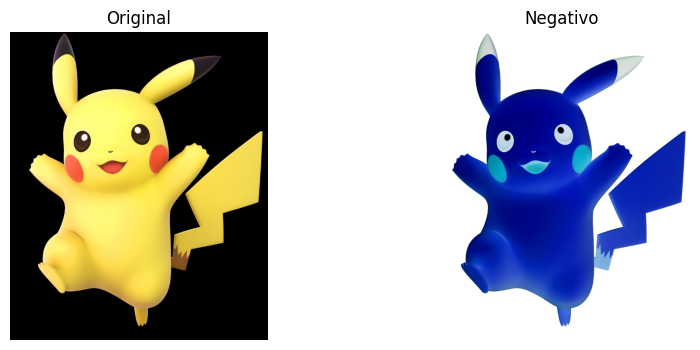

In [ ]:
img_e1 = cargar_imagen_float()
img_inv = invert_rgb(img_e1)

mostrar_comparacion(img_e1, img_inv, "Negativo")

## **Ejercicio 2: Blur de una imagen**


In [ ]:
from numba import cuda
import numpy as np

@cuda.jit
def blur_box_kernel(img_in, img_out, r):
    """
    Kernel CUDA que aplica un desenfoque tipo Box Blur sobre una imagen RGB.

    Parámetros:
    -----------
    img_in : array 3D (H, W, 3)
        Imagen de entrada en formato float32 normalizada en el rango [0,1].
    img_out : array 3D (H, W, 3)
        Imagen de salida donde se almacenará el resultado del blur.
    r : int
        Radio del kernel de convolución. El tamaño del kernel será:
        (2r+1) x (2r+1)
    """

    # Cada hilo obtiene su posición dentro de la malla 2D (pixel actual)
    j, i = cuda.grid(2)   # j = columna, i = fila

    # Dimensiones de la imagen
    H, W, C = img_in.shape

    # Verificación de límites para evitar accesos fuera de la imagen
    if i < H and j < W:

        # Acumuladores para cada canal RGB
        acc0 = 0.0
        acc1 = 0.0
        acc2 = 0.0

        # Recorrido de la vecindad definida por el radio r
        for dy in range(-r, r + 1):

            yy = i + dy  # coordenada en Y

            # Clamping en bordes (evita salir de la imagen)
            if yy < 0:
                yy = 0
            elif yy >= H:
                yy = H - 1

            for dx in range(-r, r + 1):

                xx = j + dx  # coordenada en X

                if xx < 0:
                    xx = 0
                elif xx >= W:
                    xx = W - 1

                # Suma de intensidades de los píxeles vecinos
                acc0 += img_in[yy, xx, 0]   # Canal R
                acc1 += img_in[yy, xx, 1]   # Canal G
                acc2 += img_in[yy, xx, 2]   # Canal B

        # Número total de elementos del kernel
        denom = float((2 * r + 1) * (2 * r + 1))

        # Promedio de la vecindad (operación de convolución)
        img_out[i, j, 0] = acc0 / denom
        img_out[i, j, 1] = acc1 / denom
        img_out[i, j, 2] = acc2 / denom

In [ ]:
def blur_cuda(img, r=1):
    """
    Función que gestiona la ejecución del kernel en GPU.

    Parámetros:
    -----------
    img : array 3D (H, W, 3)
        Imagen en formato float32 normalizada en el rango [0,1].
    r : int
        Radio del kernel de convolución.

    Retorna:
    --------
    Imagen desenfocada procesada en GPU.
    """

    # Dimensiones de la imagen
    H, W, C = img.shape

    # Copia de la imagen desde CPU a GPU
    d_in = cuda.to_device(img)

    # Reserva de memoria en GPU para la salida
    d_out = cuda.device_array((H, W, C), dtype=np.float32)

    # Configuración de hilos por bloque
    threadsperblock = (16, 16)

    # Cálculo del número de bloques necesarios
    blockspergrid_x = (W + threadsperblock[0] - 1) // threadsperblock[0]
    blockspergrid_y = (H + threadsperblock[1] - 1) // threadsperblock[1]
    blockspergrid = (blockspergrid_x, blockspergrid_y)

    # Lanzamiento del kernel en GPU
    blur_box_kernel[blockspergrid, threadsperblock](d_in, d_out, r)

    # Copia del resultado desde GPU a CPU
    return d_out.copy_to_host()

Saving imagen_2026-02-24_235206474.png to imagen_2026-02-24_235206474.png


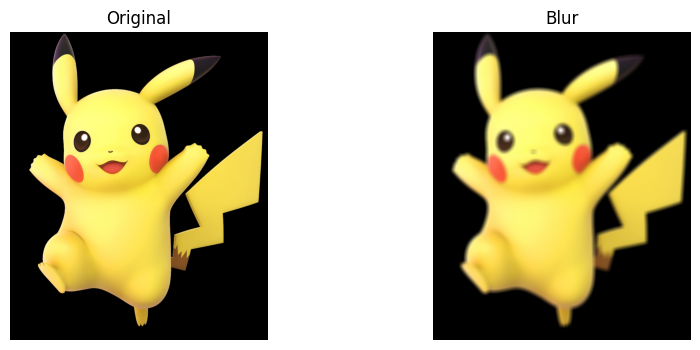

In [ ]:
img_e2 = cargar_imagen_float()
img_blur = blur_cuda(img_e2, r=9)

mostrar_comparacion(img_e2, img_blur, "Blur")

## **Ejercicio 3: Recorte de imagen**

In [ ]:
def _launch_2d(rows, cols, threads=(16, 16)):
    blocks_x = (cols + threads[0] - 1) // threads[0]
    blocks_y = (rows + threads[1] - 1) // threads[1]
    return (blocks_x, blocks_y), threads

In [ ]:
@cuda.jit
def crop_kernel_safe(img_in, img_out, x0, y0, pad_mode):
    """
    pad_mode:
      0 = strict/assume valid (se usa con validación CPU)
      1 = pad con 0 si se sale (no revienta)
    """
    j, i = cuda.grid(2)  # (col, row)

    out_rows, out_cols, ch = img_out.shape
    in_rows, in_cols, _ = img_in.shape

    if i < out_rows and j < out_cols:
        src_i = i + y0
        src_j = j + x0

        if 0 <= src_i < in_rows and 0 <= src_j < in_cols:
            img_out[i, j, 0] = img_in[src_i, src_j, 0]
            img_out[i, j, 1] = img_in[src_i, src_j, 1]
            img_out[i, j, 2] = img_in[src_i, src_j, 2]
        else:
            # Si se sale, decide qué hacer
            if pad_mode == 1:
                img_out[i, j, 0] = 0
                img_out[i, j, 1] = 0
                img_out[i, j, 2] = 0


@cuda.jit
def grayscale_kernel(img_color, img_gray):
    j, i = cuda.grid(2)
    rows, cols = img_gray.shape

    if i < rows and j < cols:
        R = img_color[i, j, 0]
        G = img_color[i, j, 1]
        B = img_color[i, j, 2]
        img_gray[i, j] = 0.2989 * R + 0.5870 * G + 0.1140 * B


@cuda.jit
def invert_rgb_kernel(img_in, img_out, inv_max):
    j, i = cuda.grid(2)
    rows, cols, ch = img_in.shape

    if i < rows and j < cols:
        img_out[i, j, 0] = inv_max - img_in[i, j, 0]
        img_out[i, j, 1] = inv_max - img_in[i, j, 1]
        img_out[i, j, 2] = inv_max - img_in[i, j, 2]

In [ ]:
def roi_from_corner(x_start, y_start, crop_w, crop_h):
    return int(x_start), int(y_start), int(crop_w), int(crop_h)

def roi_from_center(x_center, y_center, crop_w, crop_h):
    x0 = int(round(x_center - crop_w / 2))
    y0 = int(round(y_center - crop_h / 2))
    return x0, y0, int(crop_w), int(crop_h)

In [ ]:
def validate_or_fix_roi(x0, y0, crop_w, crop_h, W, H, mode="clamp"):
    """
    mode:
      - "strict": si se sale -> ValueError
      - "clamp": ajusta x0,y0,crop_w,crop_h para que quepa (reduce tamaño si toca)
      - "pad": mantiene crop_w,crop_h y permite x0,y0 fuera; kernel rellenará lo que falte
    """
    if crop_w <= 0 or crop_h <= 0:
        raise ValueError("crop_w y crop_h deben ser > 0")

    if mode == "strict":
        if x0 < 0 or y0 < 0 or x0 + crop_w > W or y0 + crop_h > H:
            raise ValueError("El recorte se sale de la imagen (modo strict).")
        return x0, y0, crop_w, crop_h

    if mode == "clamp":
        # fuerza esquina dentro; reduce tamaño para que quepa
        x0 = max(0, x0)
        y0 = max(0, y0)
        crop_w = min(crop_w, W - x0)
        crop_h = min(crop_h, H - y0)
        if crop_w <= 0 or crop_h <= 0:
            raise ValueError("ROI inválido tras clamp (queda vacío).")
        return x0, y0, crop_w, crop_h

    if mode == "pad":
        # no se cambia nada; el kernel paddea en lo que se salga
        return x0, y0, crop_w, crop_h

    raise ValueError("mode debe ser 'strict', 'clamp' o 'pad'.")

In [ ]:
def crop_image_cuda(img, x0, y0, crop_w, crop_h, mode="clamp"):
    """
    mode:
      strict -> valida en CPU, kernel asume válido
      clamp  -> ajusta para que quepa
      pad    -> mantiene tamaño y rellena con 0 fuera de la imagen
    """
    H, W, C = img.shape
    x0, y0, crop_w, crop_h = validate_or_fix_roi(x0, y0, crop_w, crop_h, W, H, mode=mode)

    d_in = cuda.to_device(img)
    d_out = cuda.device_array((crop_h, crop_w, C), dtype=img.dtype)

    pad_mode = 1 if mode == "pad" else 0
    blocks, threads = _launch_2d(crop_h, crop_w)
    crop_kernel_safe[blocks, threads](d_in, d_out, x0, y0, pad_mode)

    return d_out.copy_to_host(), (x0, y0, crop_w, crop_h)


def image_to_grayscale_cuda(img_color):
    rows, cols, ch = img_color.shape
    d_color = cuda.to_device(img_color)
    d_gray = cuda.device_array((rows, cols), dtype=np.float32)

    blocks, threads = _launch_2d(rows, cols)
    grayscale_kernel[blocks, threads](d_color, d_gray)

    return d_gray.copy_to_host()


def invert_rgb_cuda(img):
    rows, cols, ch = img.shape
    inv_max = 1.0 if img.max() <= 1.0 else 255.0

    d_in = cuda.to_device(img)
    d_out = cuda.device_array((rows, cols, ch), dtype=img.dtype)

    blocks, threads = _launch_2d(rows, cols)
    invert_rgb_kernel[blocks, threads](d_in, d_out, inv_max)

    return d_out.copy_to_host()


Saving imagen_2026-02-24_235215239.png to imagen_2026-02-24_235215239.png
Imagen original (H,W,C): (1166, 976, 3)


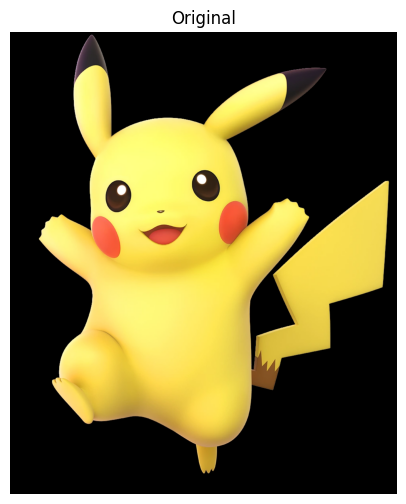

In [ ]:
uploaded = files.upload()
img_name = list(uploaded.keys())[0]

img_bgr = cv2.imread(img_name)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
# Recomendado: float32 normalizada
img = img_rgb.astype(np.float32) / 255.0
H, W, C = img.shape
print("Imagen original (H,W,C):", img.shape)
plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title("Original")
plt.axis("off")
plt.show()

In [ ]:
# 8) EJEMPLO DE USO (CROP + GRAY + INVERT)
# ============================================================
# --- Opción A: ROI por esquina (x_start,y_start)
x_start, y_start = 100, 400
crop_w, crop_h = 100, 400
x0, y0, cw, ch = roi_from_corner(x_start, y_start, crop_w, crop_h)

# --- Opción B: ROI por centro (descomenta si lo necesitas)
# x_center, y_center = W//2, H//2
# crop_w, crop_h = 500, 500
# x0, y0, cw, ch = roi_from_center(x_center, y_center, crop_w, crop_h)

# Elige modo: "strict", "clamp", "pad"
mode = "clamp"

img_crop, roi_final = crop_image_cuda(img, x0, y0, cw, ch, mode=mode)
img_gray = image_to_grayscale_cuda(img_crop)
img_inv  = invert_rgb_cuda(img_crop)

print("ROI final usado (x0,y0,w,h):", roi_final)
print("Crop shape:", img_crop.shape)


ROI final usado (x0,y0,w,h): (100, 400, 100, 400)
Crop shape: (400, 100, 3)


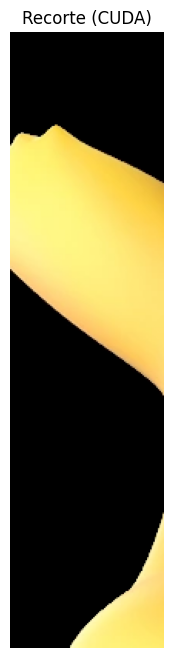

In [ ]:

plt.figure(figsize=(6, 8))
plt.imshow(img_crop if img_crop.max() <= 1 else img_crop / 255.0)
plt.title("Recorte (CUDA)")
plt.axis("off")
plt.show()

## **Ejercicio 4: Imagen Binaria (Blanco y Negro)**


In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from numba import cuda, config
from google.colab import files

config.CUDA_ENABLE_PYNVJITLINK = 1

@cuda.jit
def binarize_rgb_kernel(img_rgb_u8, out_bin_u8, T):
    x, y = cuda.grid(2)

    rows = img_rgb_u8.shape[0]
    cols = img_rgb_u8.shape[1]

    if y < rows and x < cols:
        r = img_rgb_u8[y, x, 0]
        g = img_rgb_u8[y, x, 1]
        b = img_rgb_u8[y, x, 2]

        intensity = (r + g + b) // 3
        out_bin_u8[y, x] = 255 if intensity > T else 0

def binarize_cuda(img_rgb_u8, T=128, threadsperblock=(16,16)):
    h, w, c = img_rgb_u8.shape

    d_in = cuda.to_device(img_rgb_u8)
    d_out = cuda.device_array((h, w), dtype=np.uint8)

    bx, by = threadsperblock
    blockspergrid_x = (w + bx - 1) // bx
    blockspergrid_y = (h + by - 1) // by

    binarize_rgb_kernel[(blockspergrid_x, blockspergrid_y), threadsperblock](d_in, d_out, int(T))

    return d_out.copy_to_host()

Saving imagen_2026-02-24_235221269.png to imagen_2026-02-24_235221269.png


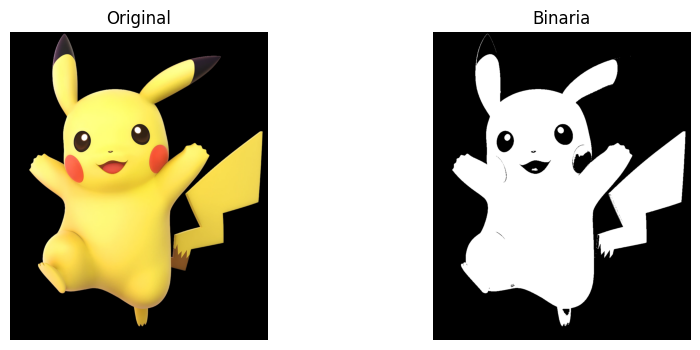

In [ ]:
img_e4 = cargar_imagen_u8()
img_bin = binarize_cuda(img_e4, T=128)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(img_e4)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Binaria")
plt.imshow(img_bin, cmap="gray", vmin=0, vmax=255)
plt.axis("off")

plt.show()

## **Ejercicio 5: Detección de Border mediante algoritmo Sobel**


In [ ]:
# ---------------------------
# KERNEL 1: RGB -> GRAYSCALE
# ---------------------------
@cuda.jit
def rgb_to_gray_kernel(img_rgb_u8, gray_u8):
    x, y = cuda.grid(2)  # x=col, y=row
    h = img_rgb_u8.shape[0]
    w = img_rgb_u8.shape[1]

    if y < h and x < w:
        r = img_rgb_u8[y, x, 0]
        g = img_rgb_u8[y, x, 1]
        b = img_rgb_u8[y, x, 2]

        # Opción sencilla (promedio):
        gray = (r + g + b) // 3

        # (Si quieres luminancia realista, reemplaza por esto):
        # gray = int(0.299*r + 0.587*g + 0.114*b)

        gray_u8[y, x] = gray

In [ ]:
# ---------------------------
# KERNEL 2: SOBEL (3x3) + MAGNITUD
# G = sqrt(Gx^2 + Gy^2)
# ---------------------------
@cuda.jit
def sobel_kernel(gray_u8, edges_u8):
    x, y = cuda.grid(2)
    h = gray_u8.shape[0]
    w = gray_u8.shape[1]

    # Para Sobel 3x3 necesitamos vecinos, entonces evitamos bordes
    if 1 <= y < h - 1 and 1 <= x < w - 1:
        # Leer vecindad 3x3 (como ints)
        p00 = int(gray_u8[y-1, x-1]); p01 = int(gray_u8[y-1, x]); p02 = int(gray_u8[y-1, x+1])
        p10 = int(gray_u8[y  , x-1]); p11 = int(gray_u8[y  , x]); p12 = int(gray_u8[y  , x+1])
        p20 = int(gray_u8[y+1, x-1]); p21 = int(gray_u8[y+1, x]); p22 = int(gray_u8[y+1, x+1])

        # Kernels Sobel:
        # Kx = [[-1, 0, 1],
        #       [-2, 0, 2],
        #       [-1, 0, 1]]
        # Ky = [[ 1,  2,  1],
        #       [ 0,  0,  0],
        #       [-1, -2, -1]]

        gx = (-1*p00) + (0*p01) + (1*p02) + (-2*p10) + (0*p11) + (2*p12) + (-1*p20) + (0*p21) + (1*p22)
        gy = ( 1*p00) + (2*p01) + (1*p02) + ( 0*p10) + (0*p11) + (0*p12) + (-1*p20) + (-2*p21) + (-1*p22)

        # Magnitud del gradiente
        gxf = float(gx)
        gyf = float(gy)
        mag = libdevice.sqrtf(gxf*gxf + gyf*gyf)

        # Clamp a [0,255]
        if mag > 255.0:
            mag = 255.0
        if mag < 0.0:
            mag = 0.0

        edges_u8[y, x] = int(mag)
    else:
        # Bordes de la imagen: los dejamos en 0
        if y < h and x < w:
            edges_u8[y, x] = 0

In [ ]:
def _launch_2d(h, w, threadsperblock=(16,16)):
    bx, by = threadsperblock
    blockspergrid_x = (w + bx - 1) // bx
    blockspergrid_y = (h + by - 1) // by
    return (blockspergrid_x, blockspergrid_y), threadsperblock

In [ ]:
def sobel_cuda(img_rgb_u8, threadsperblock=(16,16)):
    """
    img_rgb_u8: np.uint8, shape (H,W,3) en RGB (0..255)
    retorna:
      gray_u8 (H,W) y edges_u8 (H,W)
    """
    if img_rgb_u8.dtype != np.uint8:
        raise ValueError("La imagen debe ser np.uint8 (0..255).")
    if img_rgb_u8.ndim != 3 or img_rgb_u8.shape[2] != 3:
        raise ValueError("Se espera una imagen RGB (H,W,3).")

    h, w, _ = img_rgb_u8.shape

    d_rgb = cuda.to_device(img_rgb_u8)
    d_gray = cuda.device_array((h, w), dtype=np.uint8)
    d_edges = cuda.device_array((h, w), dtype=np.uint8)

    grid, block = _launch_2d(h, w, threadsperblock)

    rgb_to_gray_kernel[grid, block](d_rgb, d_gray)
    sobel_kernel[grid, block](d_gray, d_edges)

    return d_gray.copy_to_host(), d_edges.copy_to_host()

Saving imagen_2026-02-24_235228205.png to imagen_2026-02-24_235228205.png
Imagen cargada: imagen_2026-02-24_235228205.png


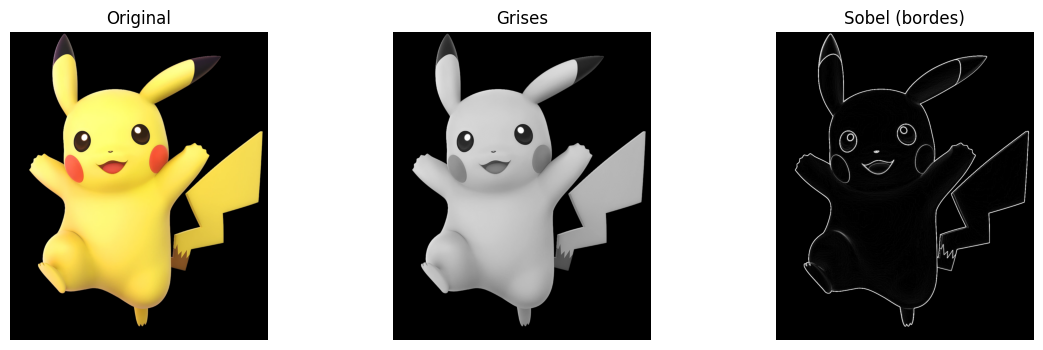

In [ ]:
uploaded = files.upload()
img_name = list(uploaded.keys())[0]
print("Imagen cargada:", img_name)

img_bgr = cv2.imdecode(np.frombuffer(uploaded[img_name], np.uint8), cv2.IMREAD_COLOR)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

gray, edges = sobel_cuda(img_rgb)

plt.figure(figsize=(14,4))
plt.subplot(1,3,1); plt.title("Original"); plt.imshow(img_rgb); plt.axis("off")
plt.subplot(1,3,2); plt.title("Grises"); plt.imshow(gray, cmap="gray", vmin=0, vmax=255); plt.axis("off")
plt.subplot(1,3,3); plt.title("Sobel (bordes)"); plt.imshow(edges, cmap="gray", vmin=0, vmax=255); plt.axis("off")
plt.show()